<a href="https://colab.research.google.com/github/PeterSpitz/cap-comp215/blob/main/Project_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Comp 215 Project 2

Joubin Eghbali

Peter Spitz



In [ ]:
%matplotlib inline

import time
from pprint import pprint

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import animation
from scipy.signal import correlate2d
import random

# Configure matplotlib's animation library to work in the browser.
matplotlib.rc('animation', html='jshtml')

In [ ]:
# Qualitative colour map with value 0 set to white
tab20_mod = matplotlib.colormaps['tab20']
tab20_mod.colors = ((1,1,1,1), *tab20_mod.colors[1:])

def plot_2d_array(array, axes=None, title='', cmap=tab20_mod, **options):
    """
    Plot the 2D array as an image on the given axes  1's will be dark blue, 0's will be light blue.

    :param axes: the axes to plot on, or None to use the `plt.gca()` (current axes)
    :param options: keyword arguments passed directly to `plt.imshow()`
           see https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html
    """
    axes = axes or plt.gca()  # If not axes are provided, draw on current axes
    axes.set_title(title)
    # Turn off axes labels and tick marks
    axes.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False ,
                     labelbottom=False, labeltop=False, labelleft=False, labelright=False,)
    # Defaults for displaying a "matrix" with hard-pixel boundaries and (0,0) at top-left
    options = {**dict(interpolation='nearest', origin='upper'), **options}
    axes.imshow(array, cmap=cmap, **options)

In [ ]:
class Animation2D:
    """
      Animates any 2D model with a step() method and a draw() method, using matplotlib
      model.step() should take no parameters - just step the model forward one step.
      model.draw() should take 2 parameters, the matpltolib axes to draw on and an integer step number

      See https://www.allendowney.com/blog/2019/07/25/matplotlib-animation-in-jupyter/
          for a discussion of the pros and cons of various animation techniques in jupyter notebooks
    """

    def __init__(self, model, frames=50, steps_per_frame=1, figsize=(8, 8)):
        """
        :param model: the simulation object to animate, with step() and draw(axes, step) methods
        :param frames: number of animation frames to generate
        """
        self.model = model
        self.frames = frames
        self.steps_per_frame = steps_per_frame
        self.fig, self.ax = plt.subplots(figsize=figsize)

    def animation_step(self, step):
        """ Step the model forward and draw the plot """
        if step > 0:
            for _ in range(self.steps_per_frame):
                self.model.step()
        self.model.draw(self.ax, step=step * self.steps_per_frame)

    def show(self):
        """ return the matplotlib animation object, ready for display """
        anim = animation.FuncAnimation(self.fig, self.animation_step, frames=self.frames)
        plt.close()  # this ensures the last frame is not shown as a separate plot
        return anim

    def animate(self, interval=None):
        """ Animate the model simulation directly in the notebook display block """
        from IPython.display import clear_output
        try:
            for i in range(self.frames):
                clear_output(wait=True)  # clear the IPython display
                self.ax.clear()  # clear old image from the axes (fixes a performance issue)
                plt.figure(self.fig)  # add the figure back to pyplot ** sigh **
                self.animation_step(i)
                plt.show()  # show the current animation frame (pyplot then closes and throws away figure ** sigh **)
                if interval:
                    time.sleep(interval)
        except KeyboardInterrupt:
            pass

In [ ]:
class Ant:

  OFF = 0
  ON = 1
  ANT_OFF = 2
  ANT_ON = 3
  MOVES = [(0,1),(-1,0),(0,-1),(1,0)] #(x,y) 0=down, 1=left, 2=up, 3=right

  # Define a colour map that maps each cell state to an intuitive colour.
  cmap = [(1, 1, 1), (0, 0, 0), (1, 0, 0), (1, 0, 0)]
  cmap[OFF] = (1, 1, 1)  #
  cmap[ON] = (0, 0, 0)  # green
  cmap[ANT_OFF] = (1, 0, 0)  # red
  cmap[ANT_ON] = (1, 0, 0)
  colour_map = matplotlib.colors.ListedColormap(cmap)

  def __init__(self, x, y, n=None, start=None, d=0):
    self.x = x
    self.y = y

    if start is None:
        self.n = n
        self.state = np.zeros((n, n), dtype=int)
    else:
        self.state = start.copy()
        self.n = len(start)

    self.state[x, y] = self.ANT_OFF
    self.direction = d

  def step(self):
    #rule: off turn clockwise, on turn left counter clockwise

    #turn and invert cell
    if self.state[self.x, self.y] == self.ANT_OFF:
      self.direction = (1 + self.direction)%4
      self.state[self.x, self.y] = self.ON
    else:
      self.direction = (3 + self.direction)%4
      self.state[self.x, self.y] = self.OFF

    #move ant
    (a,b) = self.MOVES[self.direction]

    self.x += a
    if self.x == self.n:
      self.x = 0
    elif self.x < 0:
      self.x = self.n-1

    self.y += b
    if self.y == self.n:
      self.y = 0
    elif self.y < 0:
      self.y = self.n-1

    self.state[self.x, self.y] += self.ANT_OFF

  def draw(self, axes=None, step=''):
      """Draws the CA cells using the forest colour map so values are coloured intuitively."""
      axes = axes or plt.gca()
      title = f'Time:{step}'
      plot_2d_array(self.state, axes=axes, title=title,
                    cmap=self.colour_map, vmin=0, vmax=len(self.colour_map.colors))


In [ ]:
test = Ant(1,1,3)
test.state

array([[0, 0, 0],
       [0, 2, 0],
       [0, 0, 0]])

In [ ]:
test.step()
test.state

array([[0, 2, 0],
       [0, 1, 0],
       [0, 0, 0]])

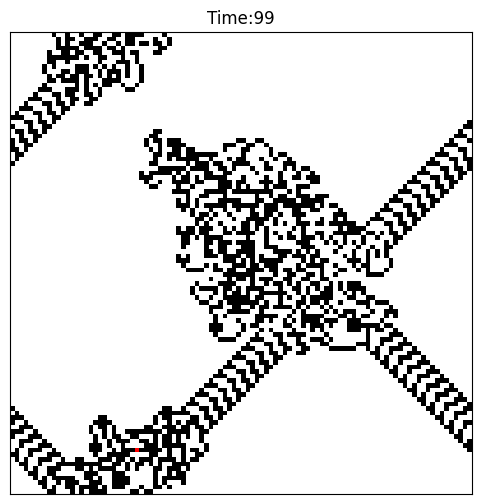

In [ ]:
m = Ant(50,50,100)

for i in range(20000):
    m.step()

test = Animation2D(m, frames=100, steps_per_frame=1, figsize=(6, 6))
test.animate(0.3)

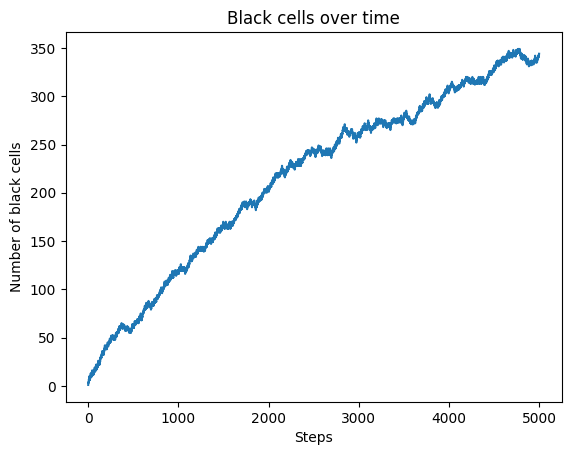

In [ ]:
steps = []
black_cells = []

m = Ant(50,50,100)

for i in range(5000):
    m.step()
    steps.append(i)
    black_cells.append(np.sum((m.state == 1) | (m.state == 3)))

plt.plot(steps, black_cells)
plt.xlabel("Steps")
plt.ylabel("Number of black cells")
plt.title("Black cells over time")
plt.show()

### Experiment 1: Black Cells Over Time

In this experiment, We tracked the number of black cells as the ant moved over 5000 steps on an initially empty grid.

The graph shows that the number of black cells generally increases over time. This suggests that the ant keeps exploring new parts of the grid and flipping more cells.

This experiment shows that even with very simple rules, Langton’s Ant produces complex behaviour and structured growth over time.

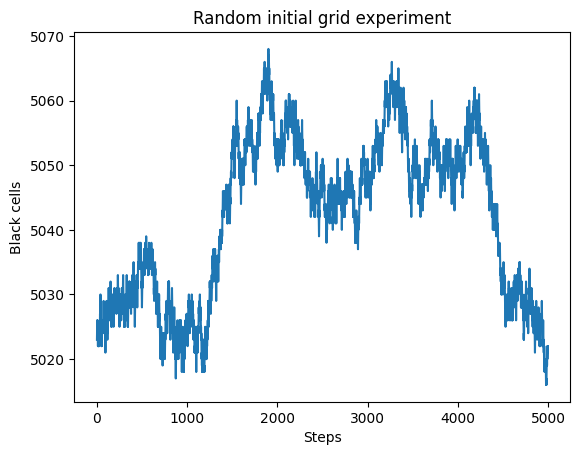

In [ ]:
# ================= EXPERIMENT 2 =================
# Random starting grid

random_state = np.random.randint(0,2,(100,100))
m2 = Ant(50,50,start=random_state)

steps2 = []
black_cells2 = []

for i in range(5000):
    m2.step()
    steps2.append(i)
    black_cells2.append(np.sum((m2.state == 1) | (m2.state == 3)))

plt.plot(steps2, black_cells2)
plt.xlabel("Steps")
plt.ylabel("Black cells")
plt.title("Random initial grid experiment")
plt.show()

In [ ]:
class Colony_ant:
  #holds only its own location

  OFF = 0
  ON = 1
  ANT_OFF = 2
  ANT_ON = 3
  MOVES = [(0,1),(-1,0),(0,-1),(1,0)] #(x,y)

  def __init__(self, x, y, d=0):
    self.x = x
    self.y = y
    self.direction = d

  def step(self, state):
    #update direction
    if state[self.x, self.y] == self.ANT_OFF:
      self.direction = (1 + self.direction)%4
    else:
      self.direction = (3 + self.direction)%4

    #check collision by calculating move
    (a,b) = self.MOVES[self.direction]

    temp_x = a + self.x
    if temp_x == len(state):
      temp_x = 0
    elif temp_x < 0:
      temp_x = len(state)-1

    temp_y = b + self.y
    if temp_y == len(state):
      temp_y = 0
    elif temp_y < 0:
      temp_y = len(state)-1

    #if no collision make move
    if state[temp_x, temp_y] < 2:
      #update old cell
      state[self.x, self.y] = (3 + state[self.x, self.y])%2

      #move
      self.x = temp_x
      self.y = temp_y

      #update new cell
      state[self.x, self.y] = (2 + state[self.x, self.y])

    return state


### Experiment 2: Random Initial Grid

In this experiment, the ant started on a grid with randomly assigned black and white cells.

Unlike Experiment 1, the number of black cells stayed relatively stable and fluctuated around a nearly constant value. This happened because the grid already began with many black cells.

This shows that Langton’s Ant is sensitive to initial conditions, and different starting grids can produce very different short-term behaviour.

In [ ]:
class Colony:
  #multiple ants. collision rule = turn, check collision, if collision do not advance nor change cell state
  #holds board. referenced by individual ants
  OFF = 0
  ON = 1
  ANT_OFF = 2
  ANT_ON = 3

  # Define a colour map that maps each cell state to an intuitive colour.
  cmap = [(1, 1, 1), (0, 0, 0), (0, 0, 1), (1, 0, 0)]
  cmap[OFF] = (1, 1, 1)
  cmap[ON] = (0, 0, 0)
  cmap[ANT_OFF] = (0, 0, 1)
  cmap[ANT_ON] = (1, 0, 0)
  colour_map = matplotlib.colors.ListedColormap(cmap)

  def __init__(self, start):
    #start is the starting board with at least 1 ant
    self.state = start
    coord = np.array(np.where(start > 1)).T
    self.ants = [Colony_ant(x,y) for (x,y) in coord]

  def step(self):
    #move each ant
    for i in range(len(self.ants)):
      self.state = self.ants[i].step(self.state)

  def draw(self, axes=None, step=''):
    """Draws the CA cells using the forest colour map so values are coloured intuitively."""
    axes = axes or plt.gca()
    title = f'Time:{step}'
    plot_2d_array(self.state, axes=axes, title=title,
                  cmap=self.colour_map, vmin=0, vmax=len(self.colour_map.colors))



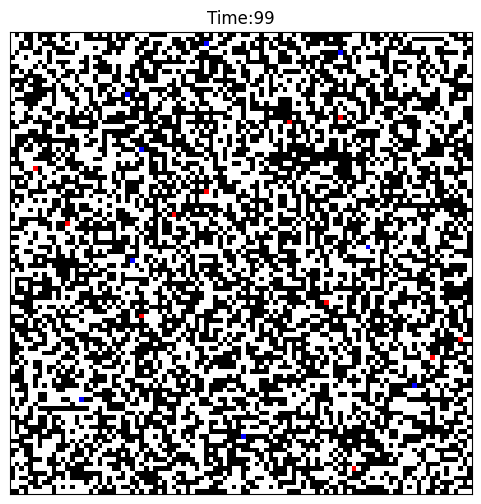

In [ ]:
ants = 20
n = 100

test = np.zeros((n,n))

i = 0
while i < ants:
  temp = (random.randint(0,n-1),random.randint(0,n-1))
  if test[temp] != 2:
    test[temp] = 2
    i += 1

m = Colony(test)

for i in range(20000):
  m.step()

test = Animation2D(m, frames=100, steps_per_frame=1, figsize=(6, 6))
test.animate(0.3)

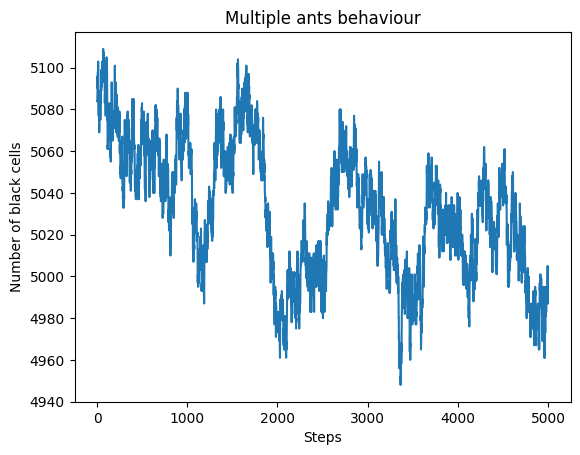

In [ ]:
# ================= EXPERIMENT 3 =================
# Compare multiple ants (Colony)

# reset colony so experiment starts fresh
m = Colony(m.state.copy())

steps3 = []
black_cells3 = []

for i in range(5000):
    m.step()
    steps3.append(i)
    black_cells3.append(np.sum((m.state == 1) | (m.state == 3)))

plt.plot(steps3, black_cells3)
plt.xlabel("Steps")
plt.ylabel("Number of black cells")
plt.title("Multiple ants behaviour")
plt.show()

### Experiment 3: Multiple Ants

In this experiment, multiple ants moved on the same grid at the same time.

Compared to the single-ant experiments, the behaviour became more irregular and complex. Since multiple ants flip cells and interact indirectly through the shared grid, the resulting pattern is harder to predict.

This suggests that adding more agents increases the complexity of the cellular automaton.

In [ ]:
# ================= TIMEIT ANALYSIS =================
import timeit

m = Ant(50,50,100)

time_100 = timeit.timeit(lambda: m.step(), number=100)
time_1000 = timeit.timeit(lambda: m.step(), number=1000)
time_10000 = timeit.timeit(lambda: m.step(), number=10000)

print("Time for 100 steps:", time_100)
print("Time for 1000 steps:", time_1000)
print("Time for 10000 steps:", time_10000)

Time for 100 steps: 9.162999958789442e-05
Time for 1000 steps: 0.0008610699997007032
Time for 10000 steps: 0.00945354900068196


### Time Complexity Analysis

Each step of the ant updates only one cell, changes direction, and moves to a neighbouring cell. Therefore, each step takes constant time, or O(1).

If the simulation runs for t steps, then the total running time is O(t).

The timeit results support this conclusion, since the runtime increases approximately in proportion to the number of steps.

The efficiency improvements discussed in Chapter 8 do not change the Big-O time complexity. They improve performance by reducing constant overhead or the multiplicative coefficient, but the growth rate remains linear.